<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
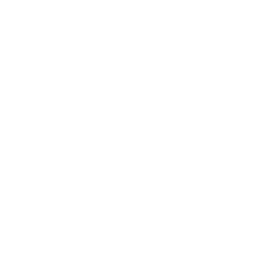
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Układ split-plot do optymalizacji procesu</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Produkcja / Inżynieria jakości &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Streszczenie kierownicze

Ten notatnik analizuje eksperyment zaplanowany w układzie split-plot dla procesu formowania wtryskowego. Czynnikiem działki całościowej (whole-plot) jest **maszyna** (4 poziomy: MACH_A-MACH_D), którą trudno zmieniać, a czynnikiem pod-działki (sub-plot) jest **ustawienie prędkości** (5 poziomów: 60, 80, 100, 120, 140 RPM), które łatwo zmieniać. Przy każdej kombinacji maszyna x prędkość wykonano pięć powtórzeń pomiarów, co daje 100 obserwacji wskaźnika wad.

`PROC MIXED` poprawnie dopasowuje strukturę ograniczonej randomizacji, traktując **maszynę jako efekt losowy** (warstwę błędu działki całościowej) i **prędkość jako efekt stały** (czynnik pod-działki). Analiza szacuje dwa składniki wariancji, testuje efekt prędkości i produkuje skorygowane metodą Tukeya porównania parami średnich LS prędkości, aby zidentyfikować prędkość roboczą minimalizującą wskaźnik wad.

## Źródła danych

| Źródło | Opis | Rekordy |
|--------|-------------|--------|
| WORK.MOLDING_EXPERIMENT | Dane eksperymentalne split-plot: 4 maszyny x 5 prędkości x 5 powtórzeń | 100 |

---

In [1]:
/* --------------------------------------------------------
   Wygenerowanie syntetycznych danych split-plot dla procesu
   formowania wtryskowego. 4 maszyny (whole-plot) x 5
   prędkości (sub-plot) x 5 powtórzeń. Dodatkowe powtórzenia
   dla każdej działki całościowej.
   -------------------------------------------------------- */
DANE work.molding_experiment;
    CALL streaminit(42);
    TABLICA machine_names[4] $12 _temporary_ ('MACH_A' 'MACH_B' 'MACH_C' 'MACH_D');
    TABLICA speed_settings[5] _temporary_ (60 80 100 120 140);
    /* Rzeczywiste efekty maszyny (losowe) */
    TABLICA mach_eff[4] _temporary_ (2.1 -1.5 0.8 -1.4);
    /* Rzeczywiste efekty prędkości (stałe, kwadratowe z optimum ok. 100) */
    TABLICA speed_eff[5] _temporary_ (3.2 1.0 -0.5 0.8 4.5);
    obs_id = 0;
    POWTÓRZ whole_plot = 1 TO 5;
        POWTÓRZ m = 1 TO 4;
            machine = machine_names[m];
            machine_id = cat('WP_', put(whole_plot, z2.), '_', machine);
            /* Efekt powtórzenia działki całościowej (whole-plot) */
            wp_noise = rand('normal', 0, 1.5);
            POWTÓRZ s = 1 TO 5;
                speed = speed_settings[s];
                speed_label = cat(put(speed, 3.), 'RPM');
                /* Powtórzenia pod-działki (sub-plot) w obrębie każdej działki */
                POWTÓRZ rep = 1 TO 5;
                    obs_id + 1;
                    /* Wskaźnik wad: wyraz wolny + maszyna + prędkość + interakcja + szum */
                    defect_rate = round(
                        8.0 + mach_eff[m] + speed_eff[s] +
                        wp_noise +
                        0.3 * (m - 2) * (s - 3) +
                        rand('normal', 0, 1.2),
                    0.01);
                    JEŚLI defect_rate < 0 WTEDY defect_rate = 0.01;
                    /* Odpowiedź wtórna: wytrzymałość na rozciąganie */
                    tensile_strength = round(
                        45 - 0.5 * defect_rate +
                        rand('normal', 0, 2),
                    0.1);
                    WYJŚCIE;
                KONIEC;
            KONIEC;
        KONIEC;
    KONIEC;
    USUŃ m s mach_eff1-mach_eff4 speed_eff1-speed_eff5 wp_noise;
WYKONAJ;



NOTE: DATA work.molding_experiment

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.molding_experiment (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.05 seconds
  cpu   0.05 seconds


---

In [2]:
/* --------------------------------------------------------
   Poziom bazowy: podsumowanie wskaźnika wad według maszyny
   i prędkości
   -------------------------------------------------------- */
PROCEDURA MEANS DANE=work.molding_experiment n mean std;
    ETYKIETA machine='Maszyna' speed_label='Ustawienie prędkości' defect_rate='Wskaźnik wad (%)' tensile_strength='Wytrzymałość na rozciąganie';
    KLASA machine speed_label;
    ZMIENNA defect_rate tensile_strength;
    TYTUŁ 'Wskaźnik wad i wytrzymałość na rozciąganie według maszyny i prędkości';
WYKONAJ;


                         Wskaźnik wad i wytrzymałość na rozciąganie według maszyny i prędkości                          

                                                  The MEANS Procedure

                                   Analysis Variable : defect_rate Wskaźnik wad (%)

        Maszyna   Ustawienie prędkości            N Obs           Mean        Std Dev
        -----------------------------------------------------------------------------
        MACH_A     60RPM                              5     12.9460000      1.0100149
        MACH_A     80RPM                              5     10.0160000      0.6740401
        MACH_A    100RPM                              5      7.5980000      0.9787083
        MACH_A    120RPM                              5     10.2660000      0.9490416
        MACH_A    140RPM                              5     13.7120000      0.9359594
        MACH_B     60RPM                              5     11.7420000      0.9476656
        MACH_B     80RPM          


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                         Wskaźnik wad i wytrzymałość na rozciąganie według maszyny i prędkości                          




NOTE: PROC MEANS
NOTE: Output dataset work.cell_means has 30 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.cell_means

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


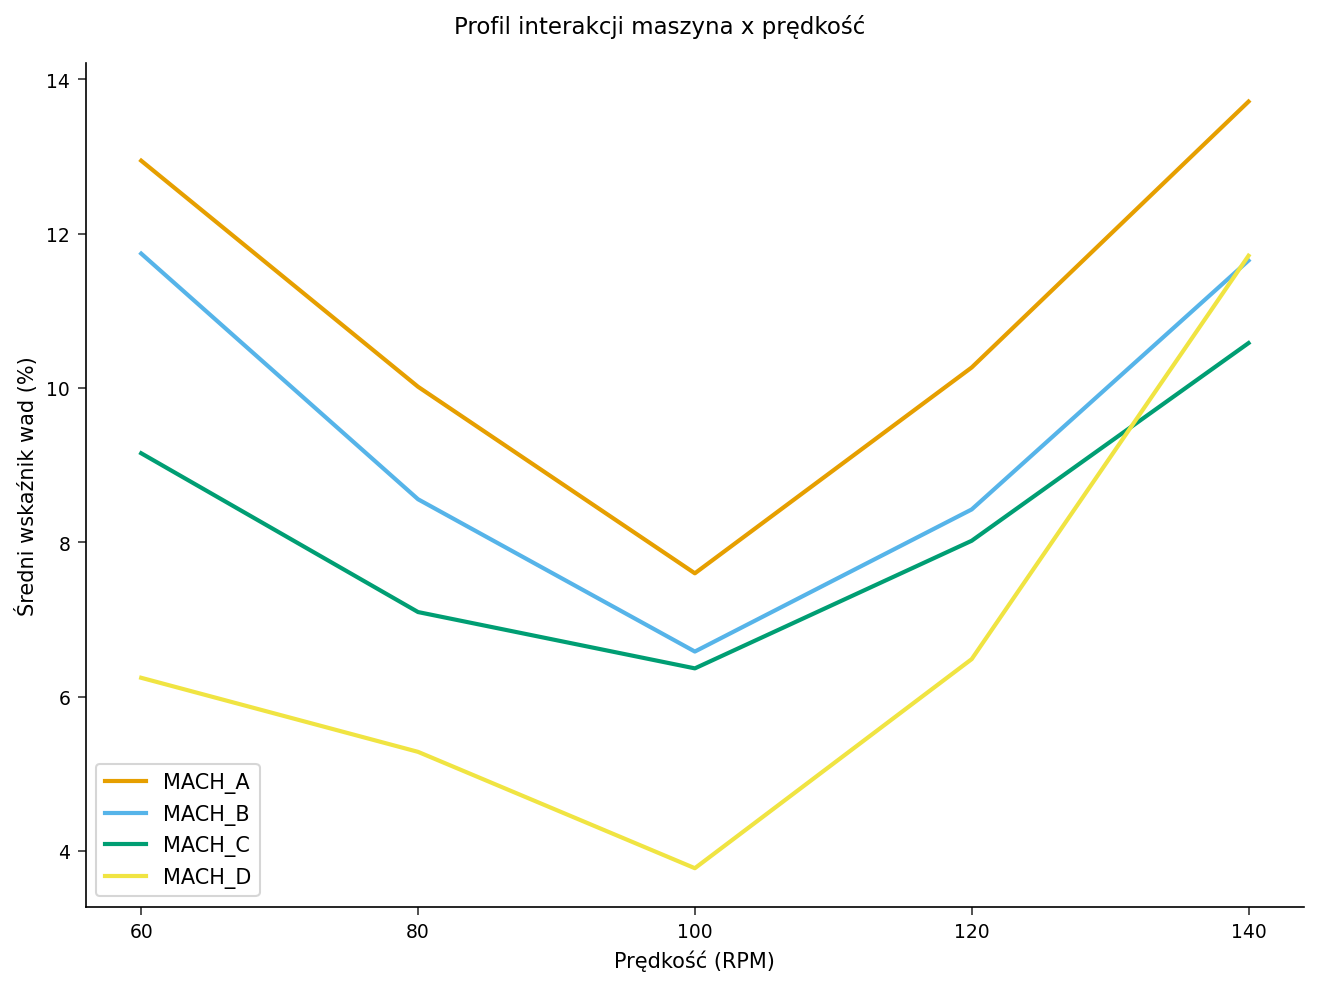

In [3]:
/* --------------------------------------------------------
   Wykres interakcji: średni wskaźnik wad według prędkości
   i maszyny
   -------------------------------------------------------- */
PROCEDURA MEANS DANE=work.molding_experiment NOPRINT;
    KLASA machine speed;
    ZMIENNA defect_rate;
    WYJŚCIE out=work.cell_means mean=mean_defect;
WYKONAJ;

PROCEDURA SGPLOT DANE=work.cell_means(GDZIE=(_type_=3));
    ETYKIETA machine='Maszyna';
    SERIES x=speed y=mean_defect / GROUP=machine
        LINEATTRS=(thickness=2) MARKERS;
    XAXIS ETYKIETA='Prędkość (RPM)' VALUES=(60 80 100 120 140);
    YAXIS ETYKIETA='Średni wskaźnik wad (%)';
    TYTUŁ 'Profil interakcji maszyna x prędkość';
WYKONAJ;


---

                         Wskaźnik wad i wytrzymałość na rozciąganie według maszyny i prędkości                          

            The Mixed Procedure             
             Model Information              

Item                                   Value
-------------------------  -----------------
Dependent Variable          Wskaźnik wad (%)
Estimation Method                       REML
Degrees of Freedom Method      Kenward-Roger
Number of Observations                   100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  machine     3.1033
Residual               1.6566

               Type III Tests of Fixed Effects                

Effect                    Num DF    Den DF   F Value    Pr > F
----------------------  --------  --------  --------  --------
Ustawienie prędkości           4      92.0     60.26    <.0001

         Fit Statistics          

Statistic                   Value
-----------------------  --------
-2 Res


NOTE: PROC MIXED data=work.molding_experiment

NOTE: PROC MIXED: using R wrapper (mixed_renderer.R).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: lmer formula: defect_rate ~ speed_label + (1 | machine)
NOTE: Warning message:
NOTE: In readLines(con = "stdin") : incomplete final line found on 'stdin'
NOTE: ODS plot written: mixed_residuals_vs_predicted.spec.json
NOTE: ODS plot written: mixed_residual_histogram_panel.spec.json
NOTE: ODS plot written: mixed_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: mixed_qq_plot.spec.json
NOTE: ODS plot written: mixed_diagnostics.spec.json
NOTE: PROC MIXED ODS Graphics generated.
NOTE: ODS OUTPUT: SolutionF written to 'split_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'split_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'speed_lsmeans'.
NOTE: ODS OUTPUT: FitStatistics written to 'split_fit'.
NOTE: ODS OUTPUT: Diffs written to 'speed_diffs'.


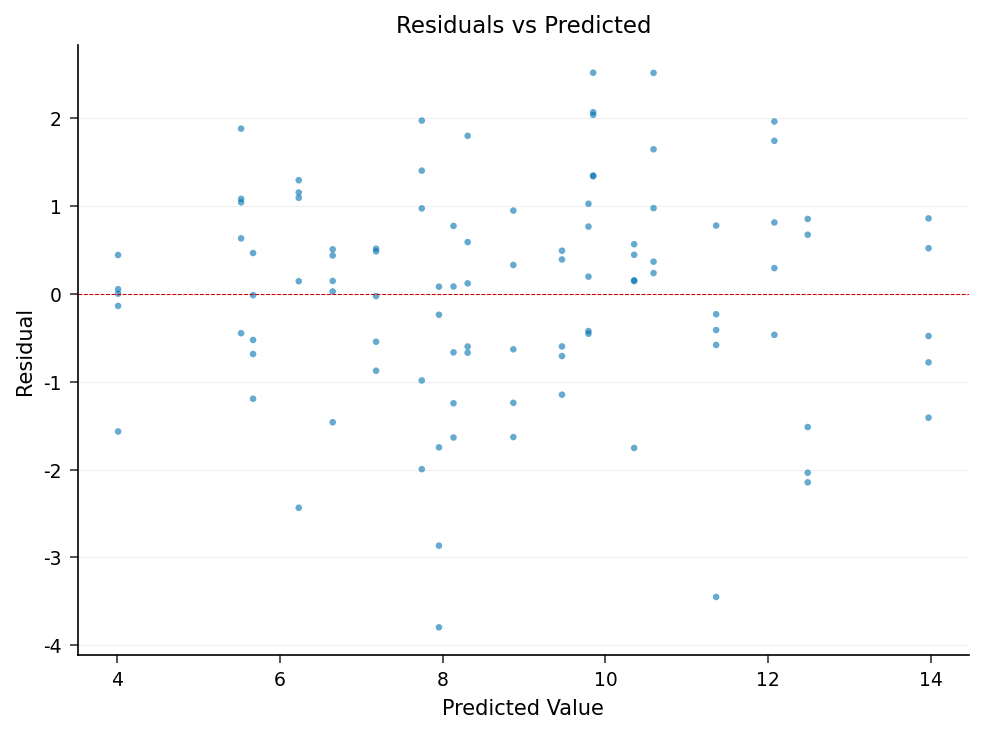

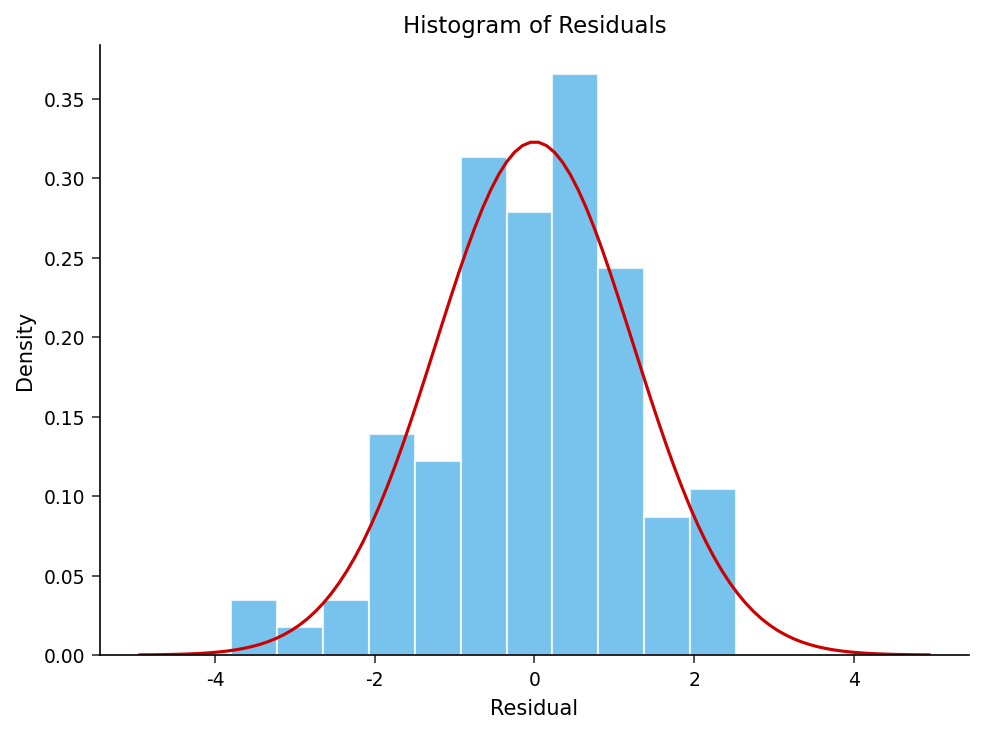

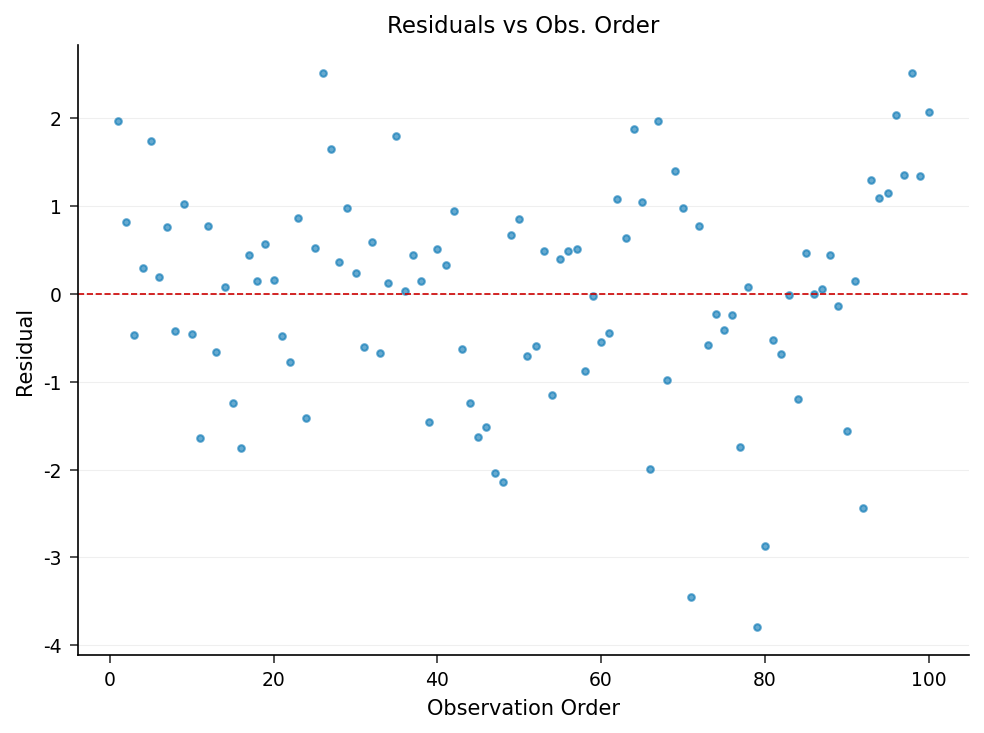

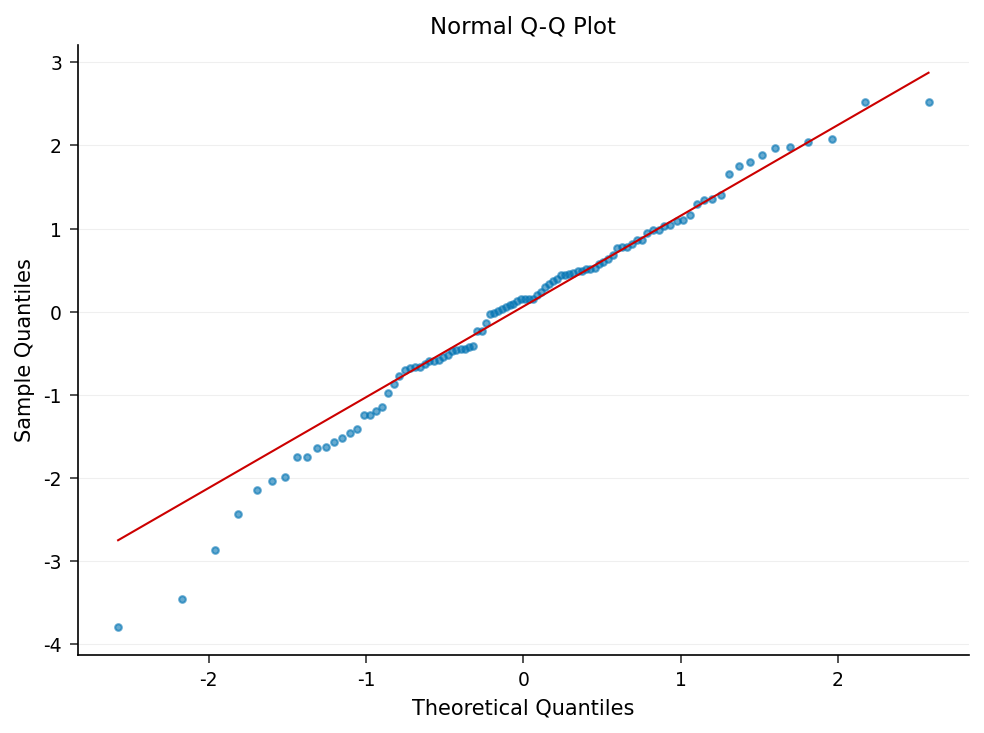

In [4]:
/* --------------------------------------------------------
   Analiza modelu mieszanego split-plot
   Maszyna jest losowa (błąd działki całościowej)
   Prędkość jest stała (czynnik pod-działki)
   -------------------------------------------------------- */
PROCEDURA MIXED DANE=work.molding_experiment METHOD=reml;
    ETYKIETA defect_rate='Wskaźnik wad (%)' machine='Maszyna' speed_label='Ustawienie prędkości';
    KLASA machine speed_label;
    MODEL defect_rate = speed_label / SOLUTION ddfm=kr;
    RANDOM machine;
    LSMEANS speed_label / ADJUST=TUKEY DIFF cl;
    ODS OUTPUT LSMEANS=work.speed_lsmeans
              diffs=work.speed_diffs
              covparms=work.split_covparms
              fitstatistics=work.split_fit
              solutionf=work.split_fixed;
    TYTUŁ 'Analiza split-plot: wpływ prędkości na wskaźnik wad';
WYKONAJ;


In [5]:
/* --------------------------------------------------------
   Identyfikacja optymalnego ustawienia prędkości
   -------------------------------------------------------- */
PROCEDURA SORT DANE=work.speed_lsmeans;
    WEDŁUG ESTIMATE;
WYKONAJ;

DANE work.optimal_speed;
    USTAW work.speed_lsmeans(obs=1);
    ZACHOWAJ speed_label ESTIMATE stderr LOWER UPPER;
    ETYKIETA speed_label = 'Optymalna prędkość'
          ESTIMATE = 'Średnia LS wskaźnika wad'
          LOWER = 'Dolna granica 95% CI'
          UPPER = 'Górna granica 95% CI';
WYKONAJ;

PROCEDURA PRINT DANE=work.optimal_speed noobs ETYKIETA;
    TYTUŁ 'Zalecana prędkość robocza dla minimalnego wskaźnika wad';
WYKONAJ;


                                Zalecana prędkość robocza dla minimalnego wskaźnika wad                                 

   Optymalna prędkość    Średnia LS wskaźnika wad  StdErr  Dolna granica 95% CI   Górna granica 95% CI
                    .                       6.081  0.9266                3.3645                 8.7975




NOTE: PROC SORT data=work.speed_lsmeans

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from work.speed_lsmeans.
NOTE: Wrote work.speed_lsmeans (5 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.optimal_speed


NOTE: Read 1 rows from work.speed_lsmeans.
NOTE: Wrote work.optimal_speed (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.optimal_speed

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


In [6]:
/* --------------------------------------------------------
   Dekompozycja składników wariancji
   -------------------------------------------------------- */
PROCEDURA PRINT DANE=work.split_covparms noobs;
    TYTUŁ 'Składniki wariancji: maszyna a reszta';
WYKONAJ;


                                         Składniki wariancji: maszyna a reszta                                          

  COVPARM  ESTIMATE
Intercept    3.1033
Residual     1.6566




NOTE: PROC PRINT data=work.split_covparms

NOTE: PROC PRINT completed: 2 observations printed, 2 variables


---

### Interpretacja

Model split-plot dzieli zmienność wskaźnika wad na dwie warstwy. **Składnik wariancji maszyny (działki całościowej) wynosi 3,10**, a **wariancja reszt (pod-działki) wynosi 1,66**, więc różnice między maszynami odpowiadają za około **65%** całkowitej wariancji (3,10 / (3,10 + 1,66)). Ten duży udział zmienności między maszynami potwierdza, że maszyna jest rzeczywistym źródłem zmienności procesu i że układ split-plot - a nie analiza w pełni zrandomizowana - jest właściwym podejściem.

Test typu III dla stałego efektu prędkości jest wysoce istotny: **F(4, 92) = 60,26, p < .0001**, więc ustawienie RPM silnie wpływa na wskaźnik wad. Średnie LS wyraźnie śledzą odpowiedź kwadratową z minimum przy prędkości środkowej:

| Prędkość | Średnia LS wskaźnika wad (%) | 95% CI |
|-------|------------------------|--------|
| **100 RPM** | **6,08** | 3,36 - 8,80 |
| 80 RPM | 7,74 | 5,02 - 10,46 |
| 120 RPM | 8,30 | 5,58 - 11,02 |
| 60 RPM | 10,02 | 7,31 - 12,74 |
| 140 RPM | 11,92 | 9,20 - 14,63 |

Porównania parami skorygowane metodą Tukeya pokazują, że **100 RPM jest istotnie niższe niż każde inne ustawienie** (skorygowane p <= 0,0009 wobec 80, 120, 60 i 140 RPM). Ustawienia 80 RPM i 120 RPM znajdują się pośrodku i **nie** różnią się między sobą (różnica 0,56, skorygowane p = 0,6430), podczas gdy 60 RPM i 140 RPM dają najwyższe wskaźniki wad.

**Rekomendacja inżynierska:** ustandaryzować produkcję przy **100 RPM** na wszystkich czterech maszynach, gdzie model szacuje najniższy wskaźnik wad (6,08%). Ponieważ składnik wariancji maszyny (3,10) jest dominującym źródłem zmienności, dalsze prace powinny skupić się na kalibracji poszczególnych maszyn - profil interakcji pokazuje, że MACH_D działa konsekwentnie najniżej, a MACH_A najwyżej - aby zmniejszyć różnicę między maszynami przy wybranym punkcie pracy 100 RPM.

---

In [7]:
/* --------------------------------------------------------
   Eksport wyników optymalizacji prędkości dla inżynierii
   -------------------------------------------------------- */
PROCEDURA EXPORT DANE=work.speed_lsmeans
    OUTFILE='speed_optimization_lsmeans.csv'
    DBMS=csv REPLACE;
WYKONAJ;

PROCEDURA EXPORT DANE=work.split_covparms
    OUTFILE='variance_components.csv'
    DBMS=csv REPLACE;
WYKONAJ;



NOTE: PROC EXPORT data=work.speed_lsmeans outfile=speed_optimization_lsmeans.csv

NOTE: Exported 5 rows to speed_optimization_lsmeans.csv.
NOTE: PROC EXPORT data=work.split_covparms outfile=variance_components.csv

NOTE: Exported 2 rows to variance_components.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Napędzane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>